### librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### data

In [40]:
DATA_PREDICTIONS_PATH = "resultados_randomwalk\\predictions_randomwalk_1993-2025_1_semana.csv"

def load_csv(path):
    return pd.read_csv(path)

In [41]:
df_predictions = load_csv(DATA_PREDICTIONS_PATH)[["date", "pred_cop_usd", "true_cop_usd", "error_abs"]]

df_predictions["date"] = pd.to_datetime(df_predictions["date"])

df_predictions["error"] = df_predictions["pred_cop_usd"] - df_predictions["true_cop_usd"]

df_predictions.head(10)

,date,pred_cop_usd,true_cop_usd,error_abs,error
0,1993-01-04,735.00000,737.979980,2.979980,-2.979980
1,1993-01-05,735.00000,737.979980,2.979980,-2.979980
2,1993-01-06,735.00000,737.979980,2.979980,-2.979980
3,1993-01-07,735.00000,737.979980,2.979980,-2.979980
4,1993-01-08,735.00000,737.979980,2.979980,-2.979980
5,1993-01-11,737.97998,737.979980,0.000000,0.000000
6,1993-01-12,737.97998,746.630005,8.650024,-8.650024
7,1993-01-13,737.97998,746.630005,8.650024,-8.650024
8,1993-01-14,737.97998,748.979980,11.000000,-11.000000
9,1993-01-15,737.97998,746.710022,8.730042,-8.730042


### plots

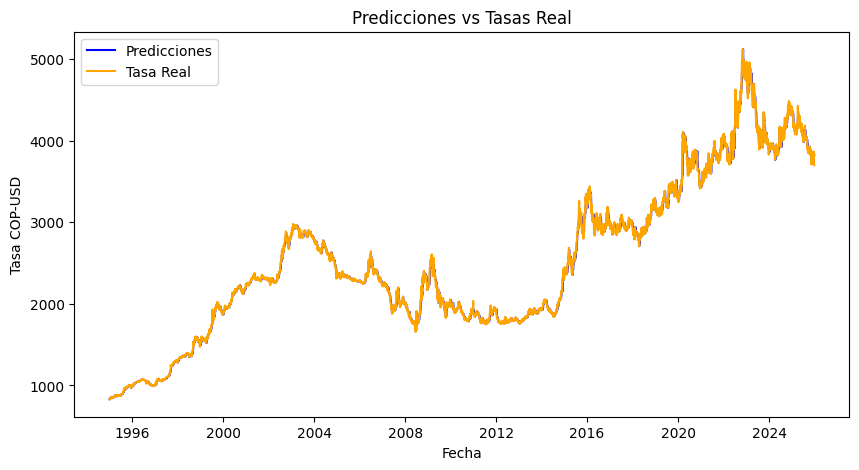

In [42]:
data_1994_2025 = df_predictions[df_predictions["date"] >= "1995-01-01"].copy()
plt.figure(figsize=(10, 5))
plt.plot(data_1994_2025["date"], data_1994_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1994_2025["date"], data_1994_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

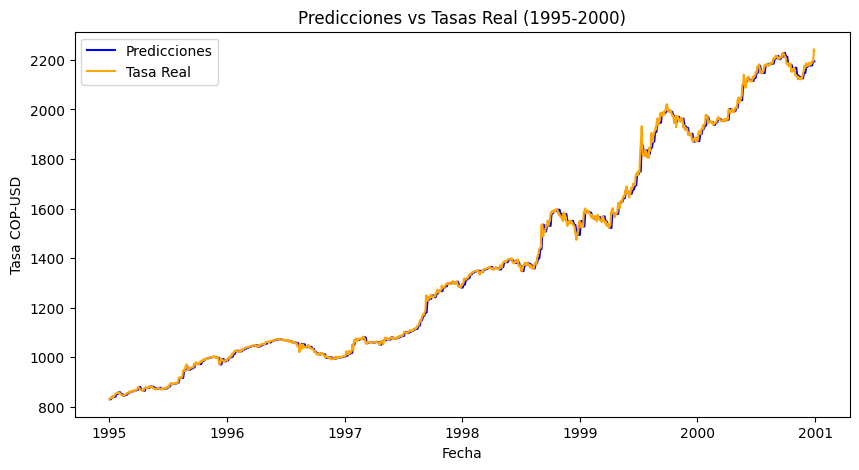

In [43]:
data_1995_2000 = df_predictions[(df_predictions["date"] >= "1995-01-01") & (df_predictions["date"] < "2001-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_1995_2000["date"], data_1995_2000["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1995_2000["date"], data_1995_2000["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (1995-2000)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

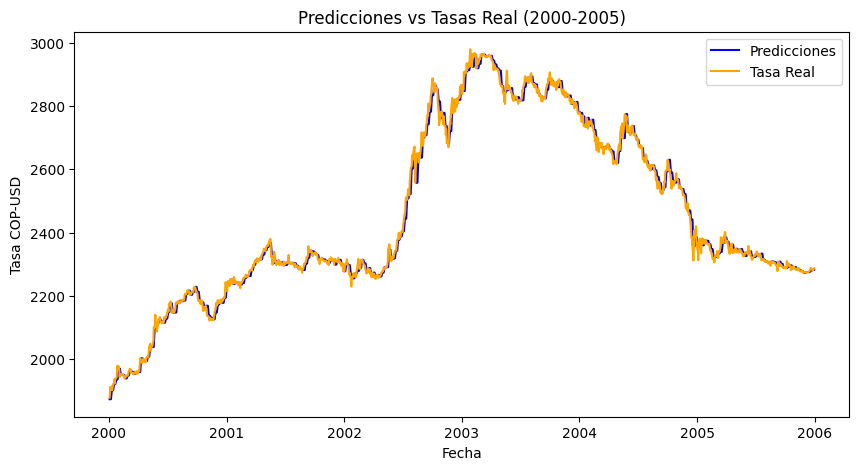

In [44]:
data_2000_2005 = df_predictions[(df_predictions["date"] >= "2000-01-01") & (df_predictions["date"] < "2006-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2000_2005["date"], data_2000_2005["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2000_2005["date"], data_2000_2005["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2000-2005)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

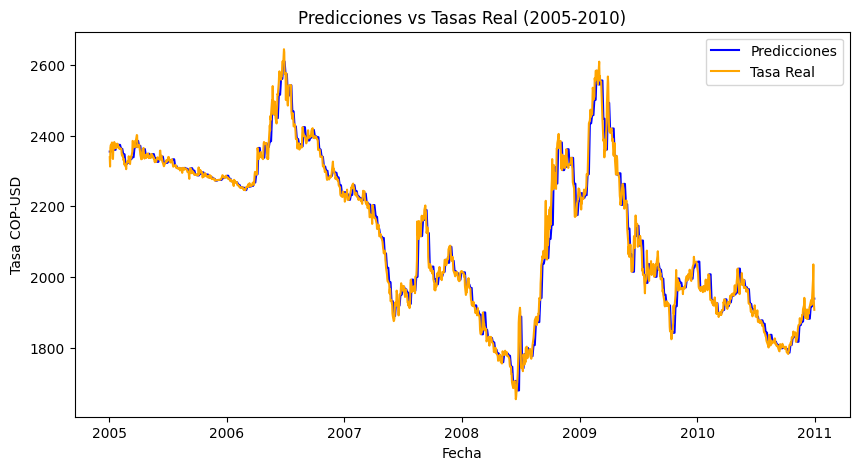

In [45]:
data_2005_2010 = df_predictions[(df_predictions["date"] >= "2005-01-01") & (df_predictions["date"] < "2011-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2005_2010["date"], data_2005_2010["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2005_2010["date"], data_2005_2010["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2005-2010)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

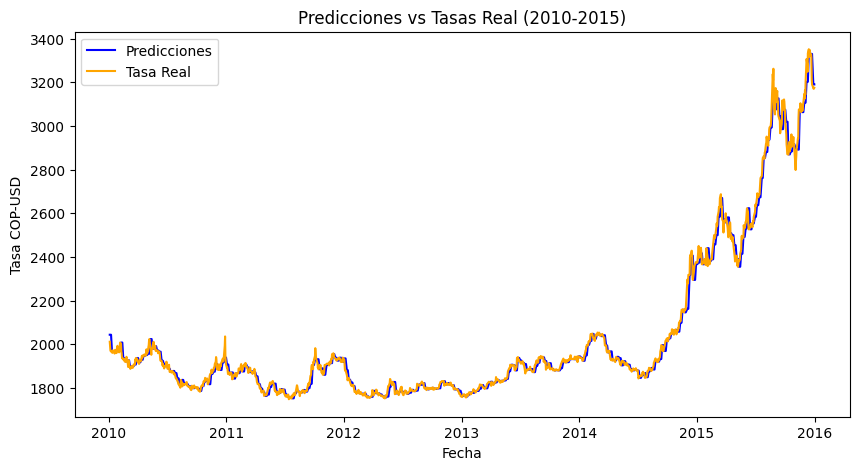

In [46]:
data_2010_2015 = df_predictions[(df_predictions["date"] >= "2010-01-01") & (df_predictions["date"] < "2016-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2010_2015["date"], data_2010_2015["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2010_2015["date"], data_2010_2015["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

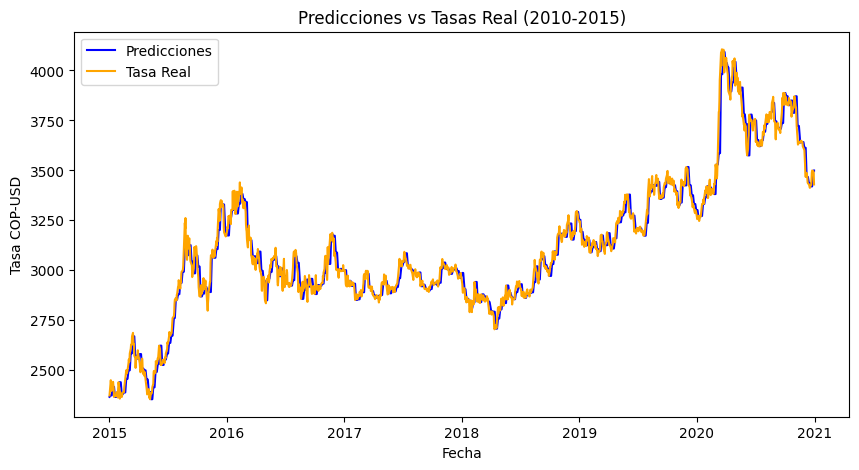

In [47]:
data_2015_2020 = df_predictions[(df_predictions["date"] >= "2015-01-01") & (df_predictions["date"] < "2021-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2015_2020["date"], data_2015_2020["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2015_2020["date"], data_2015_2020["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

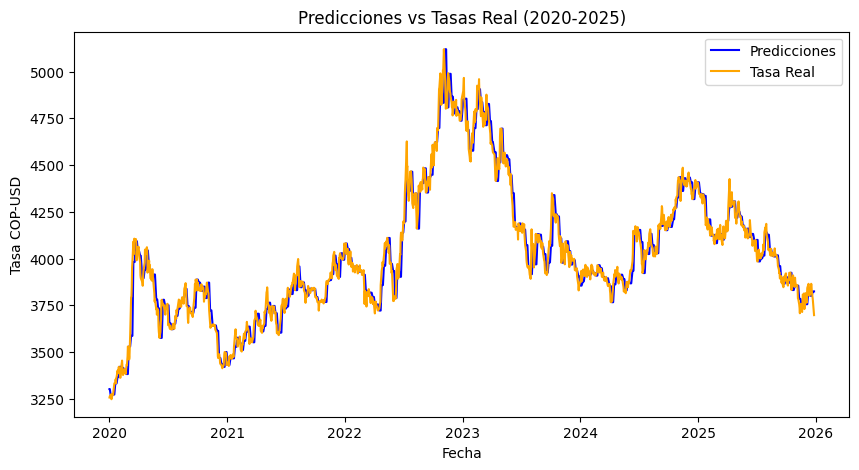

In [48]:
data_2020_2025 = df_predictions[(df_predictions["date"] >= "2020-01-01") & (df_predictions["date"] < "2026-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2020_2025["date"], data_2020_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2020_2025["date"], data_2020_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2020-2025)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

### Error Analisis

#### Sobre o Suba estimacion

In [49]:
mean_error = df_predictions["error"].mean()
dest_error = df_predictions["error"].std()
median_error = df_predictions["error"].median()

print(f"Mean error: {mean_error}")
print(f"Std Desv error: {dest_error}")
print(f"Median error: {median_error}")

# proporciones
over = np.mean(df_predictions["error"] > 0)
under = np.mean(df_predictions["error"] < 0)

print(f"Sobreestima: {over:.2%}")
print(f"Subestima: {under:.2%}")

Mean error: -2.0703939556775945
Std Desv error: 37.28949482828411
Median error: -0.4599609375
Sobreestima: 46.26%
Subestima: 52.05%


#### Distribucion del Error:

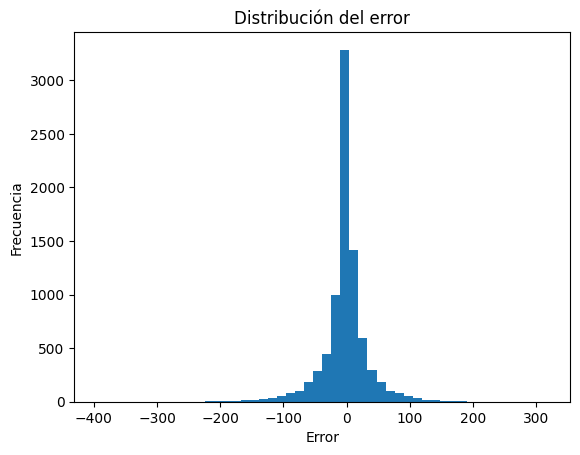

In [50]:
plt.figure()
plt.hist(df_predictions["error"], bins=50)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

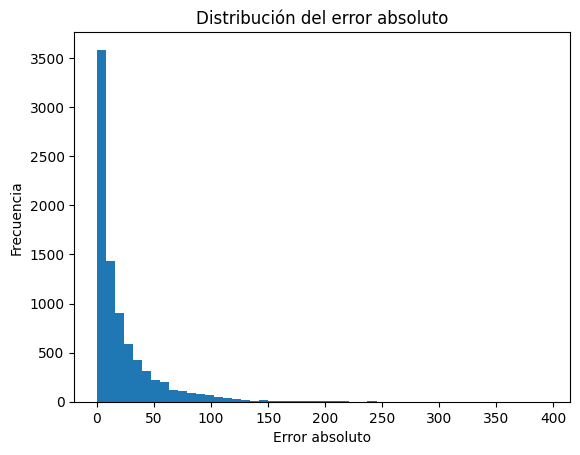

In [51]:
plt.figure()
plt.hist(df_predictions["error_abs"], bins=50)
plt.title("Distribución del error absoluto")
plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")
plt.show()

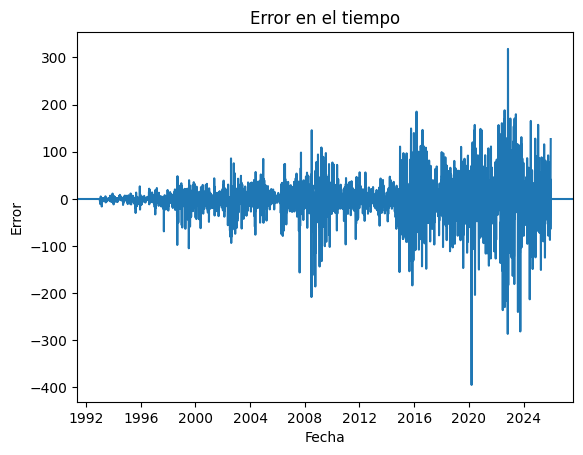

In [52]:
plt.figure()
plt.plot(df_predictions["date"], df_predictions["error"])
plt.axhline(0)
plt.title("Error en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.show()

In [53]:
errors = df_predictions["error"]

mean = errors.mean()
std = errors.std(ddof=1)
n = len(errors)

# intervalo de confianza del error medio
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

print(f"IC 95% del error medio: {ci}")

# percentiles
p_low = np.percentile(errors, 2.5)
p_high = np.percentile(errors, 97.5)

print(f"Intervalo empírico 95% del error: [{p_low}, {p_high}]")

p_low_abs = np.percentile(df_predictions["error_abs"], 2.5)
p_high_abs = np.percentile(df_predictions["error_abs"], 97.5)

print(f"Intervalo empírico 95% del error absoluto: [{p_low_abs}, {p_high_abs}]")

IC 95% del error medio: (np.float64(-2.8699930649964758), np.float64(-1.2707948463587133))
Intervalo empírico 95% del error: [-89.0039794921875, 76.701171875]
Intervalo empírico 95% del error absoluto: [0.1199951171875, 105.00900878906245]


#### plot Resampling:

In [54]:
df_predictions_time_series = df_predictions.set_index("date")

In [55]:
def analyze_errors(df, label=""):
    import numpy as np
    import matplotlib.pyplot as plt
    
    df = df.copy()
    
    df["error"] = df["pred_cop_usd"] - df["true_cop_usd"]
    df["error_abs"] = np.abs(df["error"])
    
    errors = df["error"].dropna()
    errors_abs = df["error_abs"].dropna()
    
    print(f"\n--- {label} ---")
    
    print("Mean error:", errors.mean())
    print("Std error:", errors.std())
    
    print("IC 95% error:",
          np.percentile(errors, [2.5, 97.5]))
    
    print("IC 95% error abs:",
          np.percentile(errors_abs, [2.5, 97.5]))
    
    # plots
    plt.figure()
    plt.hist(errors, bins=50)
    plt.title(f"Error distribution {label}")
    plt.show()
    
    plt.figure()
    plt.hist(errors_abs, bins=50)
    plt.title(f"Absolute error distribution {label}")
    plt.show()


--- Weekly ---
Mean error: -1.901908169532014
Std error: 32.863217808084464
IC 95% error: [-76.66065674  64.71110413]
IC 95% error abs: [ 0.26401367 88.69620239]


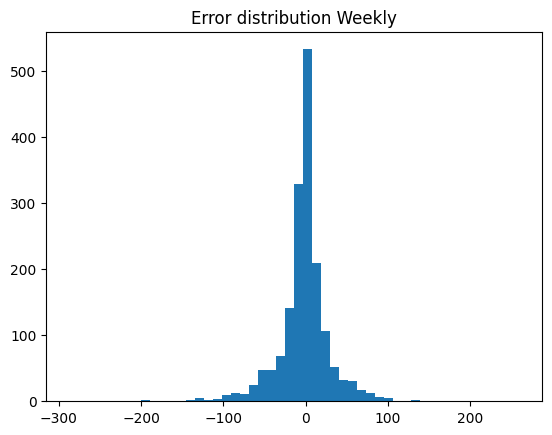

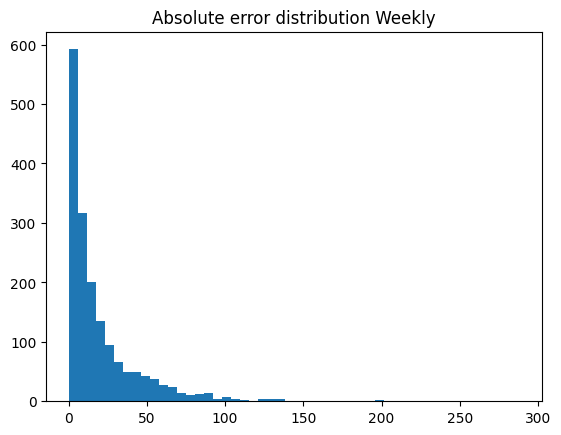

In [56]:
df_weekly = df_predictions_time_series.resample("W").mean()
analyze_errors(df_weekly, "Weekly")


--- Mothly ---
Mean error: -1.901908169532014
Std error: 32.863217808084464
IC 95% error: [-76.66065674  64.71110413]
IC 95% error abs: [ 0.26401367 88.69620239]


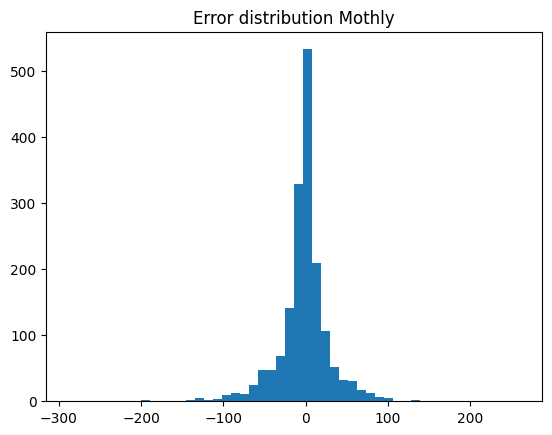

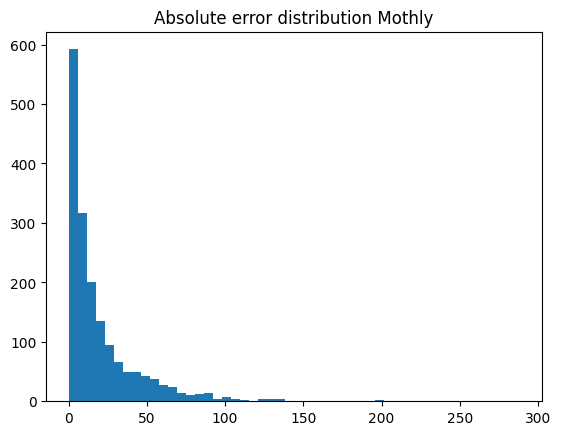

In [57]:
df_mothly = df_predictions_time_series.resample("ME").mean()
analyze_errors(df_weekly, "Mothly")


--- Yearly ---
Mean error: -1.901908169532014
Std error: 32.863217808084464
IC 95% error: [-76.66065674  64.71110413]
IC 95% error abs: [ 0.26401367 88.69620239]


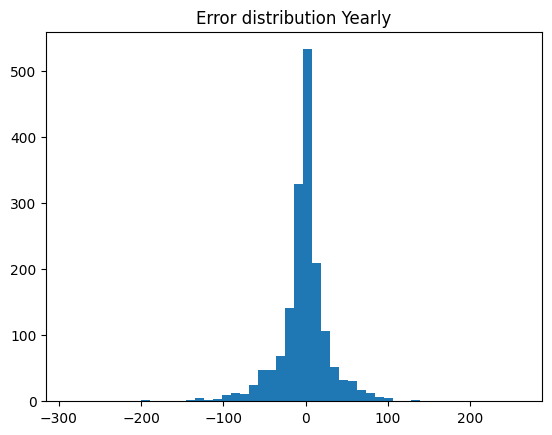

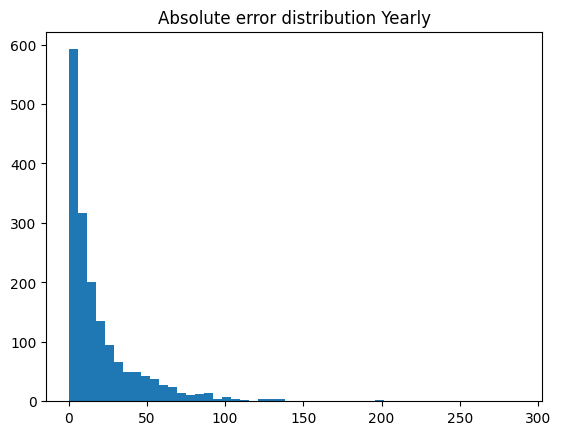

In [58]:
df_yearly = df_predictions_time_series.resample("YE").mean()
analyze_errors(df_weekly, "Yearly")